# Dataset Validation & Inspection

Check generated H5 datasets for:
- Missing/empty files
- NaN/Inf values
- Consistent shapes across simulators
- Parameter distributions (histograms)
- Spectrum summary

In [1]:
import sys
sys.path.insert(0, '/home/ubuntu/SBI4atmret')

import numpy as np
import h5py
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

## Configuration

In [2]:
# === SET THESE ===
DATA_DIR = Path("/home/ubuntu/simulations/cloudfree/")
CONFIG_PATH = "/home/ubuntu/SBI4atmret/experiments/config_MiriGeminiHST_cloudfree_aws.yaml"

# Load config for parameter names
with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

# List available simulators
sim_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])
print(f"Dataset root: {DATA_DIR}")
print(f"Simulators: {[d.name for d in sim_dirs]}")

Dataset root: /home/ubuntu/simulations/cloudfree
Simulators: ['cloudfree_gemini', 'cloudfree_hst', 'cloudfree_miri']


## 1. File Integrity Check

In [3]:
def check_file(filepath):
    """Check a single H5 file. Returns dict with status and info."""
    try:
        with h5py.File(filepath, 'r') as f:
            keys = list(f.keys())
            if not keys:
                return {"status": "EMPTY", "n": 0, "d_theta": 0, "d_x": 0, "nan": 0, "inf": 0}
            if 'theta' not in f or 'x' not in f:
                return {"status": "INVALID", "n": 0, "d_theta": 0, "d_x": 0, "nan": 0, "inf": 0}
            
            theta = f['theta'][:]
            x = f['x'][:]
            n_nan = np.isnan(x).any(axis=1).sum()
            n_inf = np.isinf(x).any(axis=1).sum()
            
            status = "OK" if (n_nan == 0 and n_inf == 0) else "WARN"
            return {
                "status": status,
                "n": theta.shape[0],
                "d_theta": theta.shape[1],
                "d_x": x.shape[1],
                "nan": int(n_nan),
                "inf": int(n_inf),
            }
    except Exception as e:
        return {"status": f"ERROR: {e}", "n": 0, "d_theta": 0, "d_x": 0, "nan": 0, "inf": 0}


for sim_dir in sim_dirs:
    print(f"\n{'═' * 60}")
    print(f"Simulator: {sim_dir.name}")
    print(f"{'═' * 60}")
    
    # Check splits
    for split in ['train', 'valid', 'test']:
        sp = sim_dir / f"{split}.h5"
        if sp.exists():
            r = check_file(sp)
            print(f"  {split}.h5: {r['status']} — {r['n']} samples, "
                  f"theta=({r['n']},{r['d_theta']}), x=({r['n']},{r['d_x']}), "
                  f"NaN={r['nan']}, Inf={r['inf']}")
        else:
            print(f"  {split}.h5: MISSING")
    
    # Check batch files
    batch_files = sorted(sim_dir.glob("samples_*.h5"))
    n_ok, n_warn, n_err, total = 0, 0, 0, 0
    dims = set()
    
    for bf in batch_files:
        r = check_file(bf)
        if r['status'] == 'OK':
            n_ok += 1
        elif r['status'] == 'WARN':
            n_warn += 1
        else:
            n_err += 1
        total += r['n']
        if r['d_x'] > 0:
            dims.add((r['d_theta'], r['d_x']))
    
    print(f"  Batches: {n_ok} OK, {n_warn} WARN, {n_err} ERROR ({len(batch_files)} files, {total} samples)")
    if len(dims) > 1:
        print(f"  ⚠️  INCONSISTENT SHAPES: {dims}")
    elif dims:
        print(f"  Shapes: theta_dim={list(dims)[0][0]}, x_dim={list(dims)[0][1]}")


════════════════════════════════════════════════════════════
Simulator: cloudfree_gemini
════════════════════════════════════════════════════════════
  train.h5: MISSING
  valid.h5: MISSING
  test.h5: MISSING
  Batches: 23 OK, 0 WARN, 0 ERROR (23 files, 77725 samples)
  Shapes: theta_dim=26, x_dim=809

════════════════════════════════════════════════════════════
Simulator: cloudfree_hst
════════════════════════════════════════════════════════════
  train.h5: MISSING
  valid.h5: MISSING
  test.h5: MISSING
  Batches: 23 OK, 0 WARN, 0 ERROR (23 files, 77725 samples)
  Shapes: theta_dim=26, x_dim=809

════════════════════════════════════════════════════════════
Simulator: cloudfree_miri
════════════════════════════════════════════════════════════
  train.h5: MISSING
  valid.h5: MISSING
  test.h5: MISSING
  Batches: 23 OK, 0 WARN, 0 ERROR (23 files, 77725 samples)
  Shapes: theta_dim=24, x_dim=1355


## 2. Cross-Simulator Alignment Check

In [4]:
# Check that all simulators have the same sample counts per batch
counts = {}
for sim_dir in sim_dirs:
    files = sorted(sim_dir.glob("samples_*.h5"))
    sc = []
    for f in files:
        try:
            with h5py.File(f, 'r') as hf:
                sc.append(hf['theta'].shape[0] if 'theta' in hf else 0)
        except:
            sc.append(-1)
    counts[sim_dir.name] = sc

names = list(counts.keys())
if len(names) >= 2:
    ref = counts[names[0]]
    all_aligned = True
    for name in names[1:]:
        if counts[name] != ref:
            mismatches = sum(1 for a, b in zip(ref, counts[name]) if a != b)
            print(f"❌ {name} vs {names[0]}: {mismatches} mismatched batches")
            all_aligned = False
    if all_aligned:
        print(f"✅ All {len(names)} simulators aligned: {len(ref)} batches, {sum(ref)} samples each")
else:
    print("Only one simulator — no alignment check.")

✅ All 3 simulators aligned: 23 batches, 77725 samples each


## 3. Parameter Histograms

In [5]:
# === Choose which simulator and split to inspect ===
SIM_NAME = sim_dirs[0].name  # e.g. "cloudfree_miri"
SPLIT = "train"  # or "valid", "test", or None to use first batch file

# Load data
filepath = DATA_DIR / SIM_NAME / f"{SPLIT}.h5"
if not filepath.exists():
    # Fall back to first batch file
    batch_files = sorted((DATA_DIR / SIM_NAME).glob("samples_*.h5"))
    filepath = batch_files[0] if batch_files else None

if filepath and filepath.exists():
    with h5py.File(filepath, 'r') as f:
        theta = f['theta'][:]
        x = f['x'][:]
    print(f"Loaded: {filepath.name} — theta {theta.shape}, x {x.shape}")
else:
    print("No data file found!")

Loaded: samples_000009.h5 — theta (3538, 26), x (3538, 809)


In [6]:
# Get parameter names from config
param_names = None
if SIM_NAME in config.get("simulator_config", {}):
    param_names = config["simulator_config"][SIM_NAME].get("kwargs", {}).get("names")

if param_names is None:
    # Fall back to prior params
    params = config.get("prior_config", {}).get("parameters", [])
    param_names = [p["name"] for p in params] if params else None

if param_names is None or len(param_names) != theta.shape[1]:
    param_names = [f"param_{i}" for i in range(theta.shape[1])]

print(f"Parameters ({len(param_names)}): {param_names[:5]}...")

Parameters (26): ['R_pl', 'mass', 'T_bottom', 'temp_node_1', 'temp_node_2']...


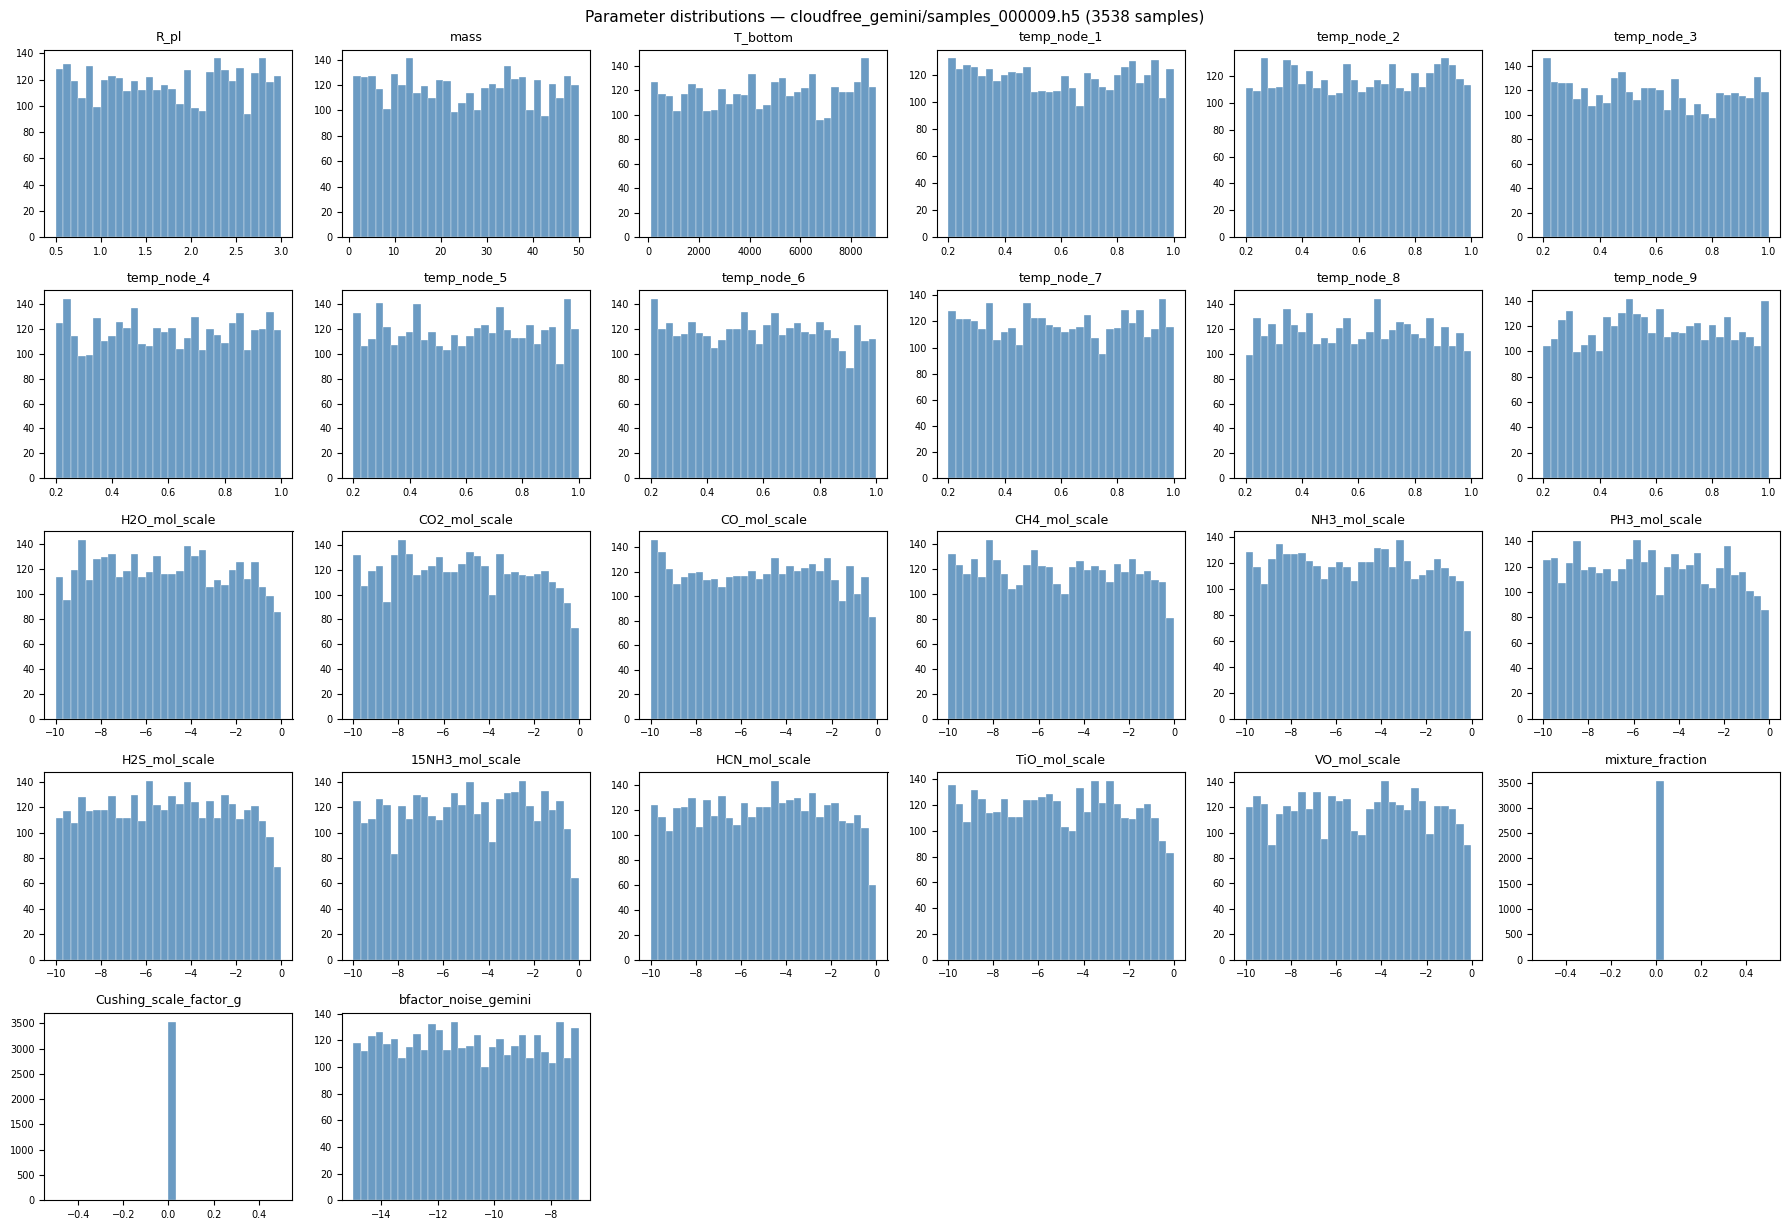

In [7]:
# Plot theta histograms
n_params = theta.shape[1]
ncols = min(6, n_params)
nrows = (n_params + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 2.5*nrows))
axes = np.atleast_2d(axes)

for i in range(n_params):
    ax = axes[i // ncols, i % ncols]
    values = theta[:, i]
    valid = values[np.isfinite(values)]
    ax.hist(valid, bins=30, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_title(param_names[i], fontsize=9)
    ax.tick_params(labelsize=7)

for i in range(n_params, nrows * ncols):
    axes[i // ncols, i % ncols].set_visible(False)

fig.suptitle(f"Parameter distributions — {SIM_NAME}/{filepath.name} ({theta.shape[0]} samples)", fontsize=11)
fig.tight_layout()
plt.show()

## 4. Spectrum Summary

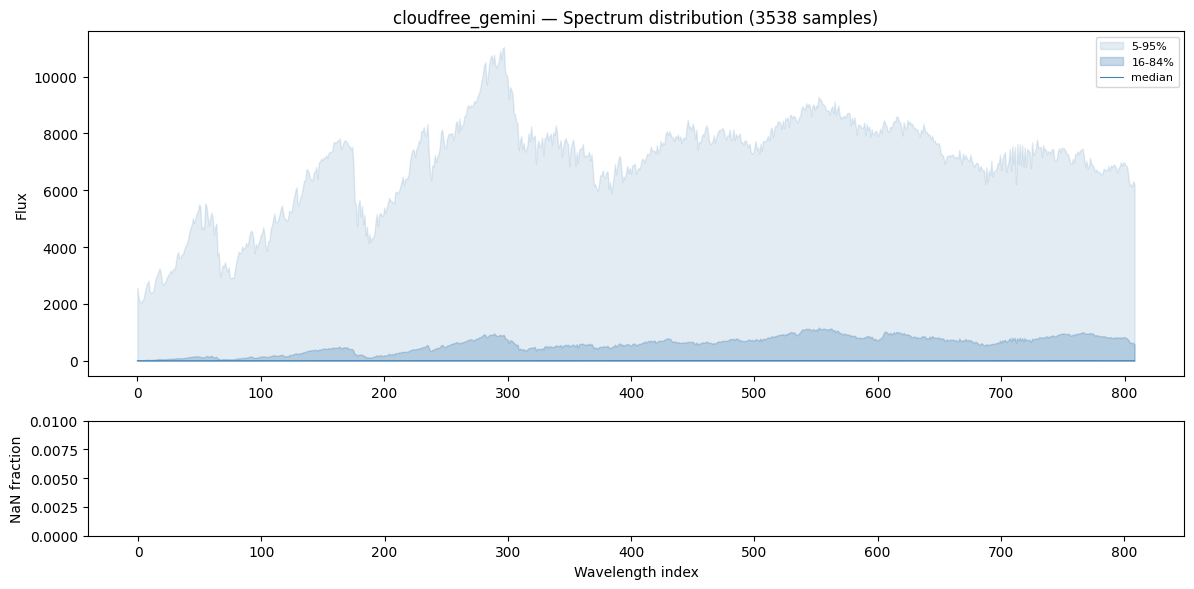

NaN samples: 0/3538
Inf samples: 0/3538


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios': [3, 1]})

# Median + percentile bands
median = np.nanmedian(x, axis=0)
p16 = np.nanpercentile(x, 16, axis=0)
p84 = np.nanpercentile(x, 84, axis=0)
p5 = np.nanpercentile(x, 5, axis=0)
p95 = np.nanpercentile(x, 95, axis=0)
idx = np.arange(x.shape[1])

ax1.fill_between(idx, p5, p95, alpha=0.15, color='steelblue', label='5-95%')
ax1.fill_between(idx, p16, p84, alpha=0.3, color='steelblue', label='16-84%')
ax1.plot(idx, median, color='steelblue', linewidth=0.8, label='median')
ax1.set_ylabel('Flux')
ax1.set_title(f'{SIM_NAME} — Spectrum distribution ({x.shape[0]} samples)')
ax1.legend(fontsize=8)

# NaN fraction per pixel
nan_frac = np.isnan(x).mean(axis=0)
ax2.bar(idx, nan_frac, color='red', alpha=0.7, width=1.0)
ax2.set_ylabel('NaN fraction')
ax2.set_xlabel('Wavelength index')
ax2.set_ylim(0, max(0.01, nan_frac.max() * 1.2))

fig.tight_layout()
plt.show()

print(f"NaN samples: {np.isnan(x).any(axis=1).sum()}/{x.shape[0]}")
print(f"Inf samples: {np.isinf(x).any(axis=1).sum()}/{x.shape[0]}")

## 5. Quick Stats

In [9]:
import pandas as pd

# Parameter statistics
stats = pd.DataFrame({
    'name': param_names,
    'mean': np.nanmean(theta, axis=0),
    'std': np.nanstd(theta, axis=0),
    'min': np.nanmin(theta, axis=0),
    'max': np.nanmax(theta, axis=0),
    'nan_count': np.isnan(theta).sum(axis=0),
})

print(stats.to_string(index=False))

                  name        mean         std        min         max  nan_count
                  R_pl    1.753299    0.731478   0.500341    2.999555          0
                  mass   25.310030   14.256356   1.024481   49.999058          0
              T_bottom 4607.238770 2591.470947 101.742104 8999.322266          0
           temp_node_1    0.596507    0.234601   0.200291    0.999932          0
           temp_node_2    0.602510    0.232318   0.200002    0.999629          0
           temp_node_3    0.592224    0.234354   0.200004    0.999806          0
           temp_node_4    0.600834    0.233236   0.200100    0.999955          0
           temp_node_5    0.599411    0.232597   0.200072    0.999883          0
           temp_node_6    0.592657    0.230490   0.200179    0.999754          0
           temp_node_7    0.598643    0.233104   0.200058    0.999852          0
           temp_node_8    0.598000    0.228174   0.200868    0.999925          0
           temp_node_9    0.